In [1]:
from pathlib import Path

from aind_hcr_data_loader import get_hcr_dataset_pairwise
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT
from aind_hcr_qc.viz.single_cell_unmixing import fig_single_cell_unmixing_mg2

In [2]:
import sys
sys.path.append("/root/capsule/code/unmix_filter_qc/")
import unmix_qc_utils

In [3]:
# notebook setup
DATA_DIR = Path('/root/capsule/data')
BUCKET_NAME = "aind-open-data"
OUTPUT_DIR = Path(f"/root/capsule/code/unmix_filter_QC/plots")

# colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}


# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [4]:
dataset, pw_ds, spots = get_hcr_dataset_pairwise(
    mouse_id="782149",
    data_dir=Path("/root/capsule/data"),   # default
    load_spots=True,                        # default
    return_removed=True,                    # include removed spots with a 'removed' column
    coreg_cells_only=True,                     # only load coregistered cells
)

coreg_df = dataset.load_coreg_table()

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-05-23_01-29-46  →  ✓ attached
  [derived_assets.czstack_hcr_coreg]  782149_2025-05-01_ctl-czstack-hcr-coreg_2026-03-03_00-00-00  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2555: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2564: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
Coreg asset attached: CoregFiles(asset='782149_2025-05-01_ctl-czstack-hcr-coreg_2026-03-03_00-00-00', coreg_table=✓, czstack_centroids=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 488, 561, 594, 405
  R2: 561, 638, 594, 488, 514, 405
  R3: 405, 594, 638, 561, 488, 514
  R4: 405, 638, 561, 514, 594, 488
  R5: 594, 488, 405, 514, 561, 638

Cell-typing: ✓  (CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✗

Spot detection files by round:
  R1: channels 488, 561, 594
    488: spots ✓, stats files: 3
    561: spot

In [15]:
coreg_df

,czstack_id,hcr_id
0,5,6711
1,14,5459
2,23,3084
3,38,5099
4,52,6282
...,...,...
298,462,36429
299,463,34020
300,464,35891
301,465,37049


In [6]:
spots = unmix_qc_utils.add_intensity_assigned_chan(spots) 

<Axes: >

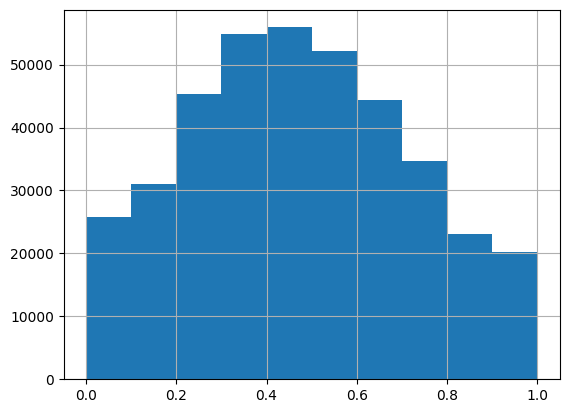

In [7]:
spots["intensity_assigned_chan_norm"].hist()

In [8]:
_test_cid = 35357
_test_rk  = "R5"


_mx = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid)]
_um = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid) & (spots["removed"] == False)]

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py

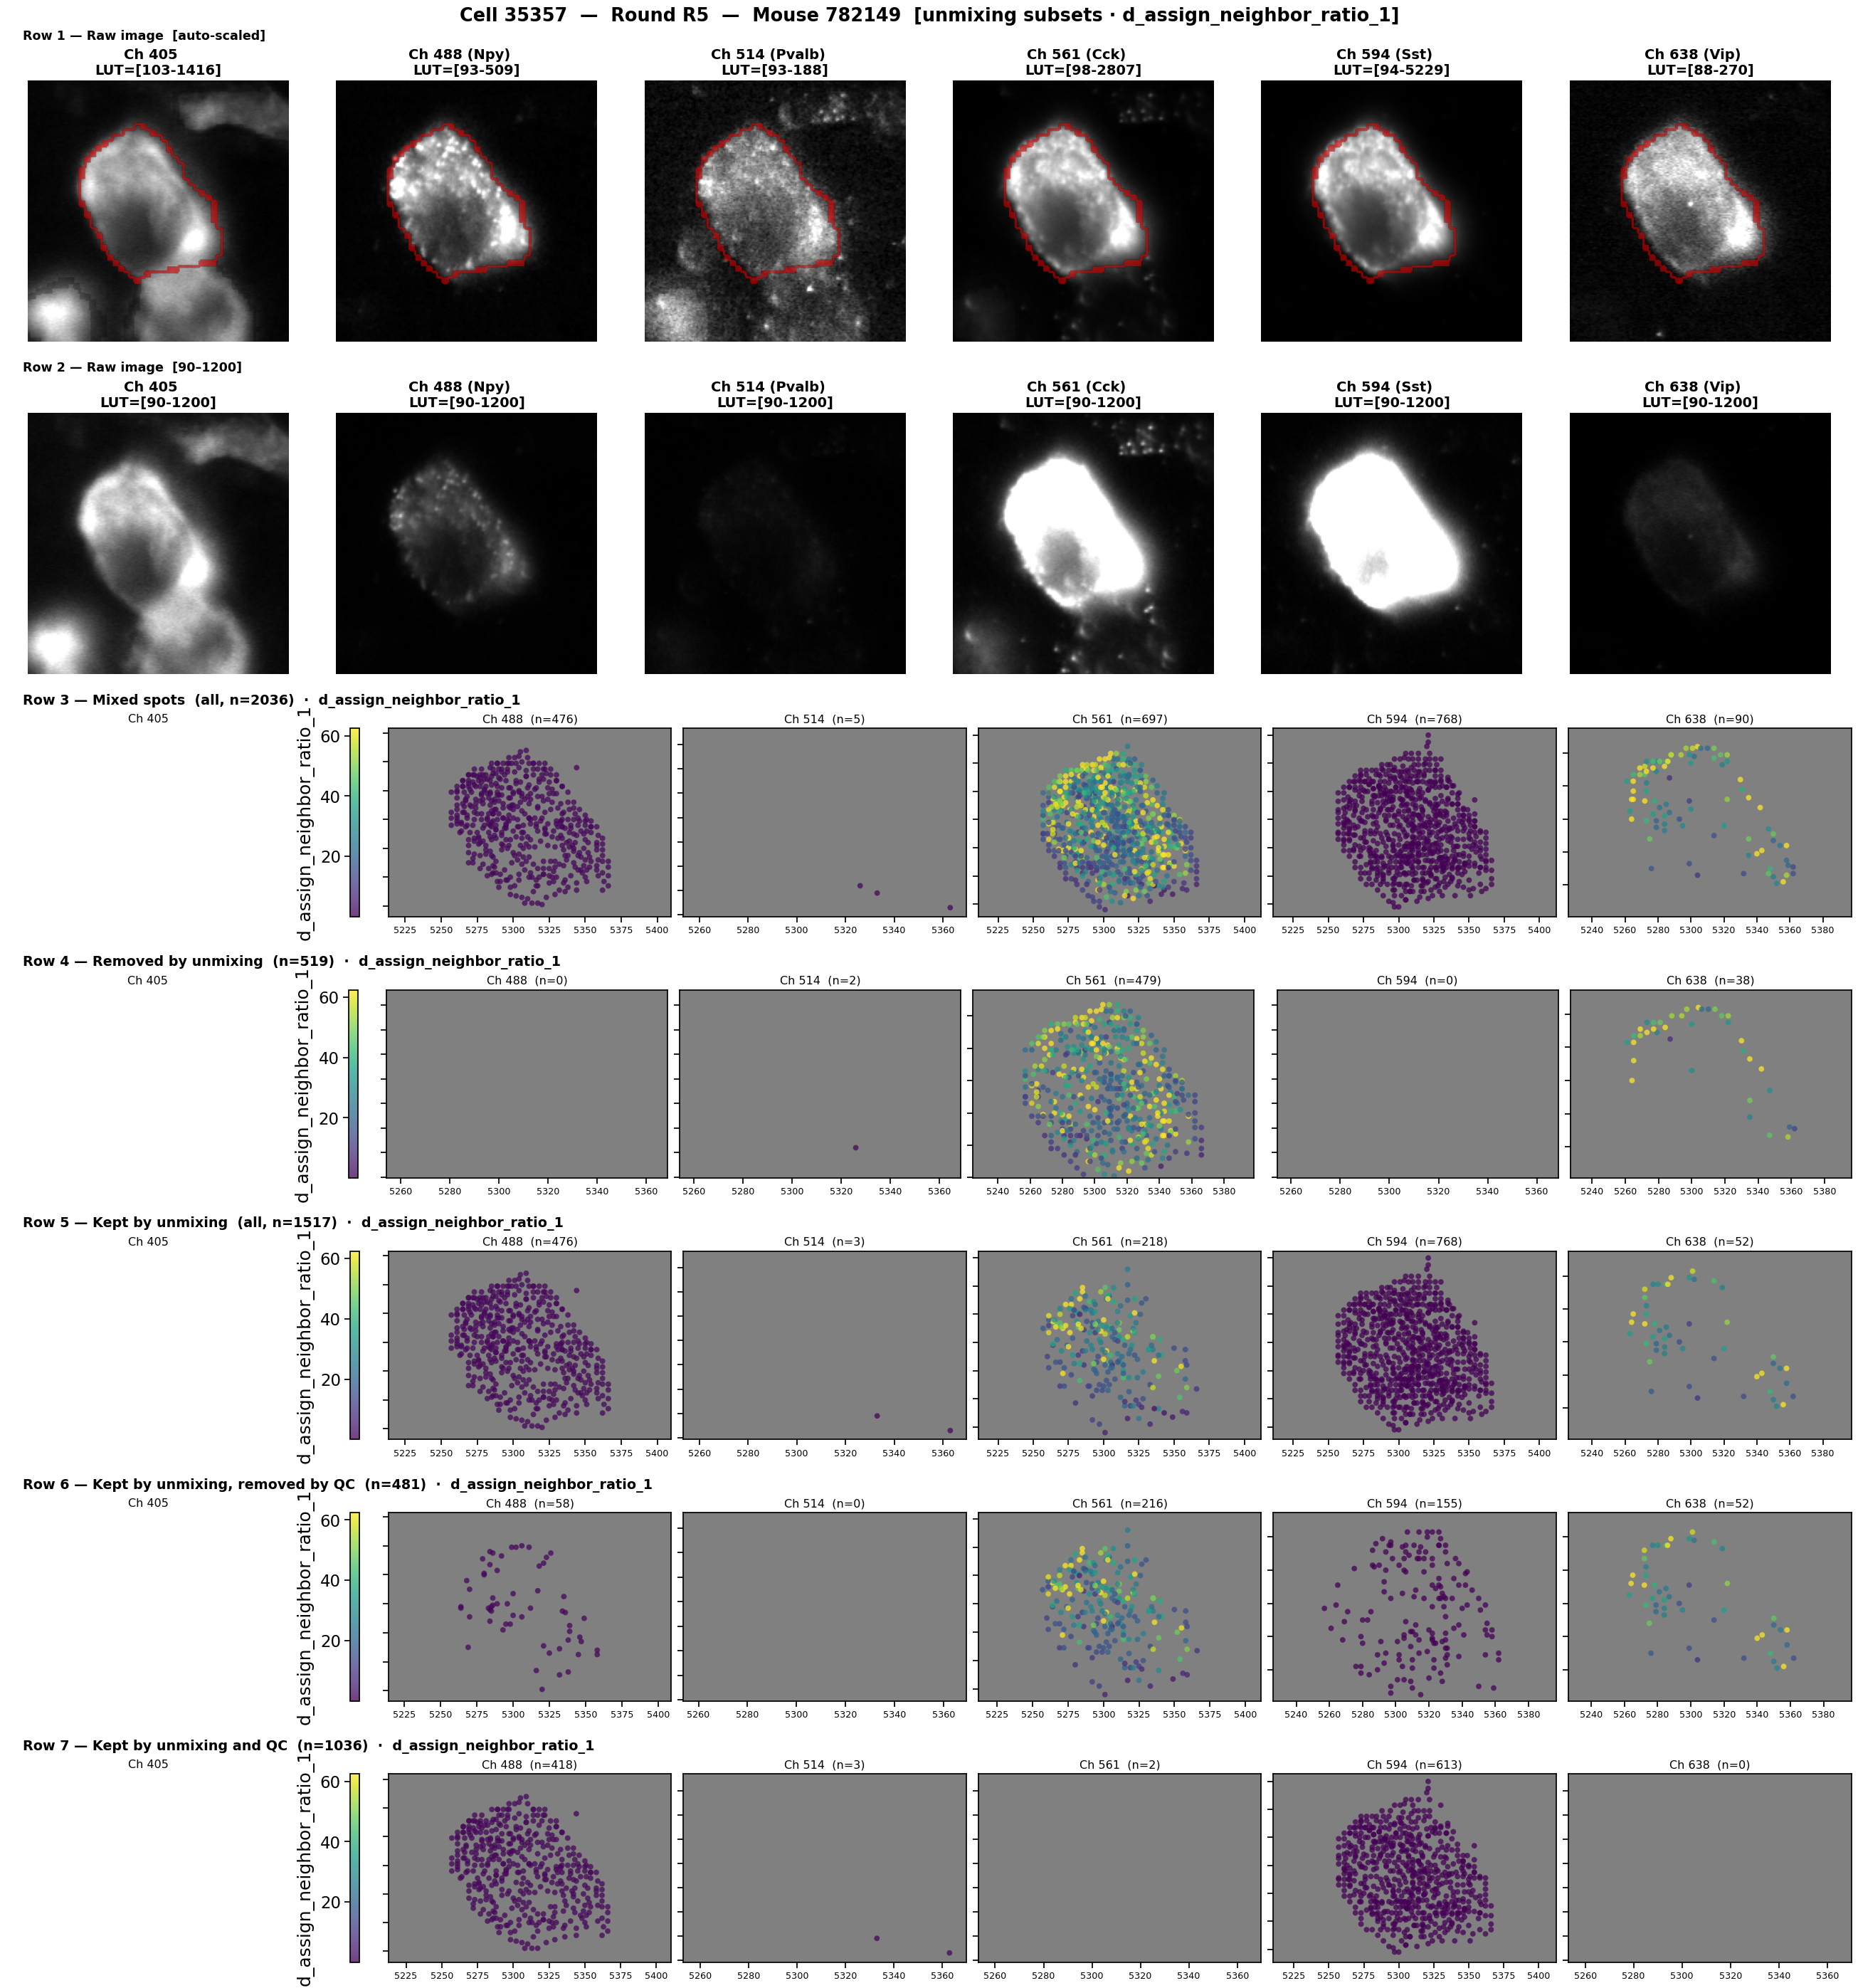

In [9]:


fig = fig_single_cell_unmixing_mg2(
    _mx, _um,
    cell_id=_test_cid, round_key=_test_rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    fast_plot=False,
    spot_size=30,
    metric_col = 'd_assign_neighbor_ratio_1'
)

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an erro

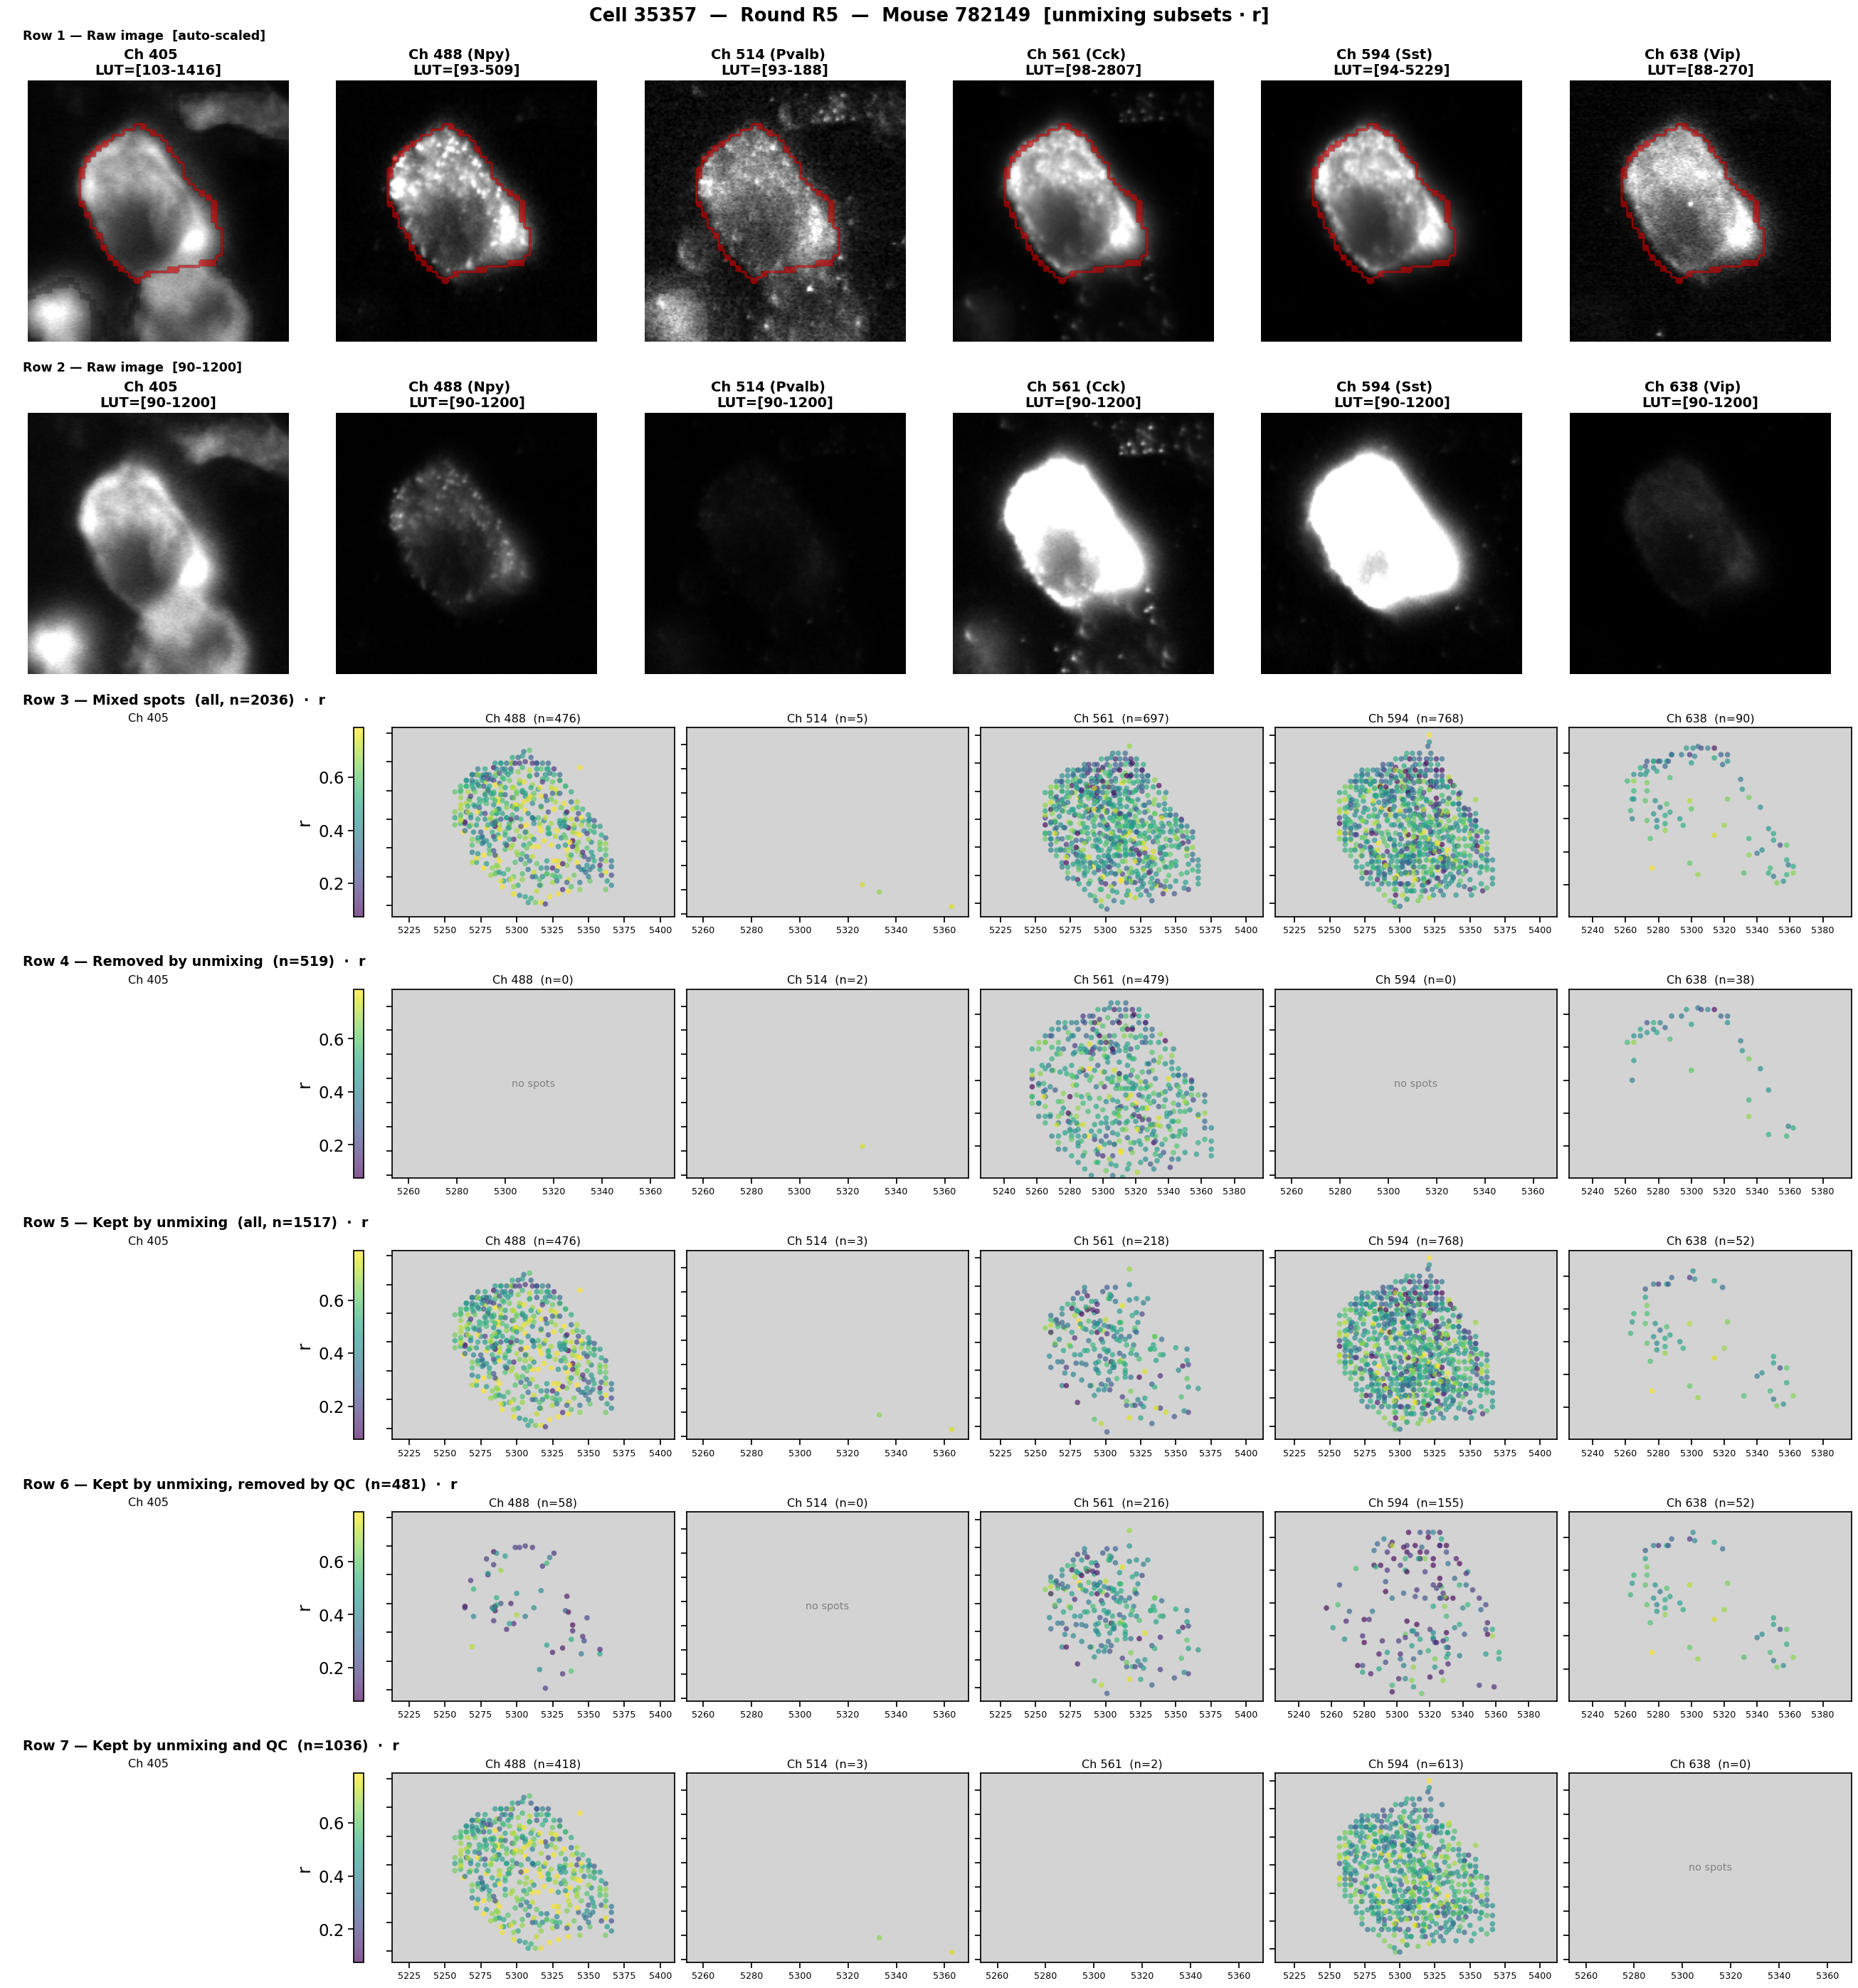

In [23]:


fig = fig_single_cell_unmixing_mg2(
    _mx, _um,
    cell_id=_test_cid, round_key=_test_rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    fast_plot=False,
    spot_size=30,
    metric_col = 'r'
)

In [ ]:
BATCH_METRICS = [
    'r',
    'dist'
    'd_assign_neighbor_ratio_1',
    'd_assign_neighbor_ratio_2',
    'dye_line_dist_ratio',
    'intensity_assigned_chan_norm',
]

batch_paths = unmix_qc_utils.batch_save_single_cell_unmixing_mg2(
    _mx,
    _um,
    cell_id=_test_cid,
    round_key=_test_rk,
    dataset=dataset,
    chan_order=CHAN_ORDER,
    chan_colors=CHAN_COLORS,
    metric_cols=BATCH_METRICS,
    output_dir=OUTPUT_DIR / 'single_cell_metric_batch',
    spot_size=30,
    fast_plot=False,
    file_ext='png',
    dpi=150,
    verbose=True,
    # filename_prefix='custom_prefix',
    # vmin=0.0,
    # vmax=1.0,
    # cmap='viridis',
)

batch_paths

# interactive

In [10]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"   # or "vscode"

In [48]:
_um.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'dist_r', 'dist_to_chan_488',
       'dist_to_chan_561', 'd_assignment_ratio', 'd_assign_neighbor_ratio_1',
       'd_assign_neighbor_ratio_2', 'nn5_dist_488', 'nn5_dist_561',
       'chan_514_intensity', 'chan_638_intensity', 'dist_to_chan_514',
       'dist_to_chan_594', 'dist_to_chan_638', 'nn5_dist_514', 'nn5_dist_594',
       'nn5_dist_638', 'removed', 'intensity_assigned_chan',
       'intensity_assigned_chan_norm'],
      dtype='object')

In [11]:
_test_cid = 35357
_test_rk  = "R5"


_mx = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid)]
_um = spots[(spots["round"] == _test_rk) & (spots["cell_id"] == _test_cid) & (spots["removed"] == False)]

In [12]:
import sys
sys.path.append("/root/capsule/code/unmix_filter_qc")
import unmix_qc_utils

w = unmix_qc_utils.interactive_single_cell_unmixing_plotly(
    _mx, _um,
    cell_id=_test_cid,
    round_key=_test_rk,
    chan_order=CHAN_ORDER,
    axis_limits="global"
)



In [13]:
display(w)

## Cell browser dashboard
Use the browser widget to step through a curated list of cells, jump to a specific cell id, change rounds, and swap metrics/colormaps while keeping the same Plotly layout.

In [14]:
browser = unmix_qc_utils.interactive_single_cell_browser_plotly(
    spots=spots,
    chan_order=CHAN_ORDER,
    round_key=_test_rk,
    start_cell_id=_test_cid,
    cell_ids=sorted(spots.loc[spots["round"] == _test_rk, "cell_id"].unique()),
    axis_limits="global",
)

display(browser)